In [1]:
from funcs import set_env
set_env()

### Data

In [ ]:
from blocking import train_test_sets

data, train_pairs, test_pairs = train_test_sets() # type: ignore

print("-" * 60)
print("DATA")

print("Shape:", data.shape)
print("Columns:")
print(data.columns.tolist())
print("Index:")
print(data.index.name)

print("\n" + "-" * 60)
print("TRAIN PAIRS")
print("Shape:", train_pairs.shape)
print(train_pairs.columns.tolist())

print("\n" + "-" * 60)
print("TEST PAIRS")
print("Shape:", test_pairs.shape)
print(test_pairs.columns.tolist())

Loading Candidate Pairs from file...
Total Candidate Pairs from Union of Rule-based and LSH Blocking: 378655
------------------------------------------------------------
DATA
Shape: (50000, 12)
Columns:
['first_name', 'last_name', 'phone', 'dob', 'city', 'state', 'postal_code', 'street_number', 'street_name', 'apt_number', 'email_user', 'email_domain']
Index:
record_id

------------------------------------------------------------
TRAIN PAIRS
Shape: (302924, 3)
['record_id_1', 'record_id_2', 'label']

------------------------------------------------------------
TEST PAIRS
Shape: (75731, 3)
['record_id_1', 'record_id_2', 'label']


In [3]:
for fields in data.columns:
    print(data[fields].str.len().max())

11
20
10
8
23
2
5
5
26
3
25
22


### Test the character vocabulary

In [4]:
import string

PAD_IDX = 0
UNK_IDX = 1
chars = string.ascii_lowercase + string.digits + " .,/-'"
char_to_idx = { char: idx + 2 for idx, char in enumerate(chars) }
vocab_size = len(char_to_idx) + 2

print("Vocabulary size:", vocab_size)

for char, idx in list(char_to_idx.items())[:30]:
    print(repr(char), "→", idx)

print("PAD:", PAD_IDX)
print("UNK:", UNK_IDX)



Vocabulary size: 44
'a' → 2
'b' → 3
'c' → 4
'd' → 5
'e' → 6
'f' → 7
'g' → 8
'h' → 9
'i' → 10
'j' → 11
'k' → 12
'l' → 13
'm' → 14
'n' → 15
'o' → 16
'p' → 17
'q' → 18
'r' → 19
's' → 20
't' → 21
'u' → 22
'v' → 23
'w' → 24
'x' → 25
'y' → 26
'z' → 27
'0' → 28
'1' → 29
'2' → 30
'3' → 31
PAD: 0
UNK: 1


### Tokenization

In [5]:
import torch

def char_tokenizer(text, max_len=26):
      text = str(text).lower()
      tokens = []
      for char in text:
            tokens.append(char_to_idx.get(char, UNK_IDX))
      tokens = tokens[:max_len] # truncate
      tokens += [PAD_IDX] * (max_len - len(tokens)) # padding

      return torch.tensor(tokens, dtype=torch.long)

example_text = str(data.iloc[0]["first_name"])
print("Original:")
print(example_text)
tokens = char_tokenizer(example_text, max_len=50)
print("\nToken IDs:")
print(tokens)
print("\nShape:")
print(tokens.shape)

Original:
danielle

Token IDs:
tensor([ 5,  2, 15, 10,  6, 13, 13,  6,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

Shape:
torch.Size([50])


### Datasets

In [6]:
from feature_extractor import data

train_data, test_data, train_loader, test_loader = data()

features_A, features_B, label = train_data[0]

print("Label:", label)

fields = features_A.keys()
print("\nFields:", fields)

for field in fields:

    print(f"\n--- {field} ---")

    print("A:")
    print(features_A[field])
    print("Shape:", features_A[field].shape)

    print("B:")
    print(features_B[field])
    print("Shape:", features_B[field].shape)

Loading Candidate Pairs from file...
Total Candidate Pairs from Union of Rule-based and LSH Blocking: 378655
Label: tensor(1.)

Fields: dict_keys(['first_name', 'last_name', 'phone', 'dob', 'city', 'state', 'postal_code', 'street_number', 'street_name', 'apt_number', 'email_user', 'email_domain'])

--- first_name ---
A:
tensor([20,  9,  2, 15, 15, 16, 15,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])
Shape: torch.Size([50])
B:
tensor([20,  9,  2, 15, 15, 16, 15,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])
Shape: torch.Size([50])

--- last_name ---
A:
tensor([ 3, 19,  2,  5, 20,  9,  2, 24,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,

### See the pairs

In [7]:
def show_pair(dataset, idx, fields):

    row = dataset.pairs.iloc[idx]

    record_A = dataset.data.loc[row["record_id_1"]]
    record_B = dataset.data.loc[row["record_id_2"]]

    print("=" * 70)
    print(f"PAIR {idx}")
    print("=" * 70)

    print("Record A:", row["record_id_1"])
    print("Record B:", row["record_id_2"])
    print("LABEL:", row["label"])

    for field in fields:

        print(f"\n[{field}]")

        print("A:", record_A[field])
        print("B:", record_B[field])

positive_idx = train_pairs.index[train_pairs["label"] == 1][0]
negative_idx = train_pairs.index[train_pairs["label"] == 0][0]

       
show_pair(train_data, positive_idx, fields)
show_pair(train_data, negative_idx, fields)

PAIR 253295
Record A: rec_27070
Record B: rec_6224_dup6224
LABEL: 0

[first_name]
A: curtis
B: samantha

[last_name]
A: harris
B: harris

[phone]
A: 5017114820
B: 3046602883

[dob]
A: 19740408
B: 19691223

[city]
A: westfurt
B: lakeamberville

[state]
A: ar
B: wv

[postal_code]
A: 72016
B: 25921

[street_number]
A: 00260
B: 04023

[street_name]
A: ramirezspringssuite
B: moorefieldsuite

[apt_number]
A: 112
B: 282

[email_user]
A: harrisc9074
B: meganharris

[email_domain]
A: aol
B: gmail
PAIR 58728
Record A: rec_1185
Record B: rec_38320
LABEL: 0

[first_name]
A: john
B: katelyn

[last_name]
A: johnson
B: johnson

[phone]
A: 3168241528
B: 2143733606

[dob]
A: 19470125
B: 19890619

[city]
A: eastadam
B: eastmatthew

[state]
A: ks
B: tx

[postal_code]
A: 67112
B: 76435

[street_number]
A: 00322
B: 73363

[street_name]
A: kruegergateway
B: garciatrace

[apt_number]
A: 000
B: 135

[email_user]
A: johnson_john
B: kjohnson859

[email_domain]
A: outlook
B: bennett


### Test loader

In [8]:
batch_A, batch_B, labels = next(iter(train_loader))

print("Labels:")
print(labels)

print("\nBatch shapes:")

for field in fields:

    print(
        field,
        "A:", batch_A[field].shape,
        "B:", batch_B[field].shape
    )

Labels:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.])

Batch shapes:
first_name A: torch.Size([128, 50]) B: torch.Size([128, 50])
last_name A: torch.Size([128, 50]) B: torch.Size([128, 50])
phone A: torch.Size([128, 50]) B: torch.Size([128, 50])
dob A: torch.Size([128, 50]) B: torch.Size([128, 50])
city A: torch.Size([128, 50]) B: torch.Size([128, 50])
state A: torch.Size([128, 50]) B: torch.Size([128, 50])
postal_code A: torch.Size([128, 50]) B: torch.Size([128, 5

In [9]:
from feature_extractor import CharCNN
from funcs import get_device

device = get_device()
cnn = CharCNN().to(device)
name_batch = batch_A["first_name"].to(device)

embedding = cnn(name_batch)

print("Input:")
print(name_batch.shape)

print("\nEmbedding:")
print(embedding.shape)

Input:
torch.Size([128, 50])

Embedding:
torch.Size([128, 128])


### Complete EntityMatcher

In [10]:
from feature_extractor import EntityMatcher

model = EntityMatcher(
    vocab_size=vocab_size,
    fields=fields,
    embedding_dim=128
).to(device)

In [ ]:
batch_A, batch_B, labels = next(iter(train_loader))
batch_A = {field: batch_A[field].to(device) for field in fields}
batch_B = {field: batch_B[field].to(device) for field in fields}

labels = labels.to(device)

with torch.no_grad():
    logits, embeddings_A, embeddings_B = model(
        batch_A,
        batch_B,
        return_embeddings=True
    )

print("Logits:")
print(logits)

print("\nLogits shape:")
print(logits.shape)

Logits:
tensor([ 0.2522,  0.3490,  0.4047,  0.3933,  0.2279,  0.2406,  0.2061,  0.6482,
         0.2396,  0.5103, -0.0129,  0.4672,  0.1744,  0.3635,  0.1835,  0.2721,
         0.0491,  0.5100,  0.1591,  0.2402,  0.4364,  0.3653,  0.1159,  0.1793,
         0.1522,  0.3641,  0.1403,  0.2971,  0.0789,  0.4515,  0.1426,  0.3668,
         0.3321,  0.1344,  0.2678,  0.2611,  0.3000,  0.1999,  0.6286,  0.3550,
         0.1533,  0.1896,  0.5835,  0.3197,  0.0988,  0.1623,  0.1931,  0.3546,
         0.2829,  0.1881,  0.1709,  0.2071,  0.4499,  0.2094,  0.3859,  0.2048,
         0.3527,  0.1161,  0.3203,  0.5327,  0.2871,  0.1315,  0.7457, -0.0392,
         0.1295,  0.4799,  0.2903,  0.5481,  0.2210,  0.1253,  0.4937,  0.1328,
         0.2847,  0.3968,  0.2831,  0.4822,  0.1730,  0.0106,  0.3229,  0.2445,
        -0.0563,  0.2368,  0.1529,  0.1529,  0.3329,  0.1325,  0.2725,  0.2612,
         0.4867,  0.2383,  0.1348,  0.5115,  0.1239,  0.4623,  0.3661,  0.2149,
        -0.0139,  0.1755,  0.178

### Embeddings

In [12]:
for field in fields:
    print(f"{field:15s}", "A:", tuple(embeddings_A[field].shape),
        "B:", tuple(embeddings_B[field].shape)
    )

first_name      A: (128, 128) B: (128, 128)
last_name       A: (128, 128) B: (128, 128)
phone           A: (128, 128) B: (128, 128)
dob             A: (128, 128) B: (128, 128)
city            A: (128, 128) B: (128, 128)
state           A: (128, 128) B: (128, 128)
postal_code     A: (128, 128) B: (128, 128)
street_number   A: (128, 128) B: (128, 128)
street_name     A: (128, 128) B: (128, 128)
apt_number      A: (128, 128) B: (128, 128)
email_user      A: (128, 128) B: (128, 128)
email_domain    A: (128, 128) B: (128, 128)


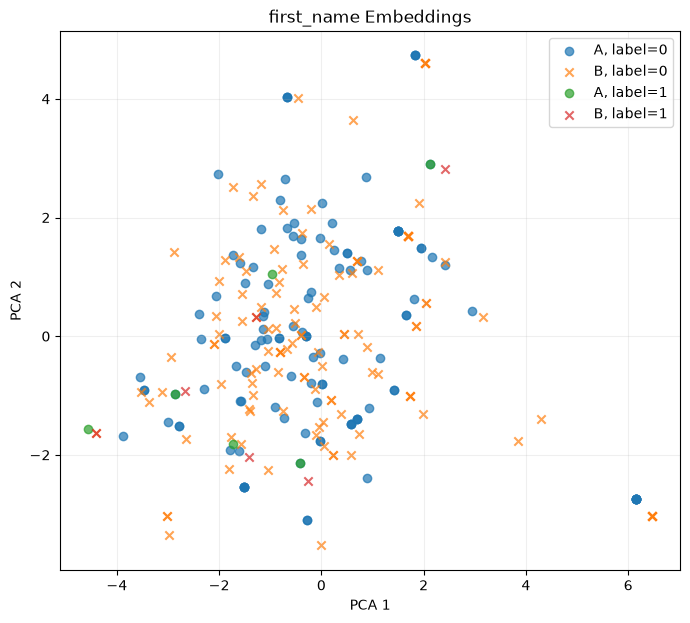

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


def visualize_field_embeddings( embeddings_A, embeddings_B, labels, field):

    A = embeddings_A[field].detach().cpu().numpy()
    B = embeddings_B[field].detach().cpu().numpy()

    labels = labels.cpu().numpy()
    all_embeddings = np.vstack([A, B])
    pca = PCA(n_components=2)
    coords = pca.fit_transform(all_embeddings)
    n = len(A)

    A_coords = coords[:n]
    B_coords = coords[n:]

    plt.figure(figsize=(8, 7))

    for label in [0, 1]:
        mask = labels == label
        plt.scatter(
            A_coords[mask, 0],
            A_coords[mask, 1],
            label=f"A, label={label}",
            alpha=0.7
        )

        plt.scatter(
            B_coords[mask, 0],
            B_coords[mask, 1],
            marker="x",
            label=f"B, label={label}",
            alpha=0.7
        )

    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"{field} Embeddings")

    plt.legend()
    plt.grid(alpha=0.2)

    plt.show()

visualize_field_embeddings(embeddings_A, embeddings_B, labels, field="first_name")

### Field Similarity

In [20]:
import torch.nn.functional as F

def field_similarities(embeddings_A, embeddings_B, fields):
    similarities = {}
    for field in fields:
        A = embeddings_A[field]
        B = embeddings_B[field]
        sim = F.cosine_similarity(A, B, dim=1)
        similarities[field] = sim.detach().cpu()

    return similarities

similarities = field_similarities(embeddings_A, embeddings_B, fields)
for field in fields:
    print(field, similarities[field])

first_name tensor([0.9909, 0.3115, 0.5534, 0.9934, 0.2397, 0.2742, 0.4735, 0.1930, 0.1217,
        0.2520, 0.2535, 0.3642, 0.2914, 0.5943, 0.4819, 0.4172, 0.2597, 0.3036,
        0.2506, 0.3713, 0.9940, 0.9939, 0.9894, 0.9909, 0.9910, 0.2828, 0.2082,
        0.2557, 0.9872, 0.2068, 0.9931, 0.3274, 0.3519, 0.9935, 0.2567, 0.4560,
        0.4711, 0.3528, 0.4350, 0.3657, 0.9850, 0.5883, 0.3734, 0.9931, 0.4152,
        0.4946, 0.5202, 0.2900, 0.4566, 0.5322, 0.2976, 0.5233, 0.3817, 0.4933,
        0.3539, 0.3825, 0.6716, 0.2164, 0.2649, 0.9939, 0.9893, 0.2927, 0.9915,
        0.3253, 0.4259, 0.3259, 0.9939, 0.2989, 0.1262, 0.9909, 0.4505, 0.9885,
        0.5033, 0.3161, 0.3749, 0.4662, 0.3967, 0.3158, 0.2260, 0.9909, 0.9909,
        0.9878, 0.3297, 0.9930, 0.9876, 0.2257, 0.1290, 0.9862, 0.9910, 0.2032,
        0.9937, 0.2926, 0.9923, 0.4550, 0.9851, 0.3701, 0.2166, 0.2555, 0.9938,
        0.4007, 0.3054, 0.2529, 0.1337, 0.2843, 0.2229, 0.1970, 0.2722, 0.4706,
        0.9939, 0.2955, 0.308

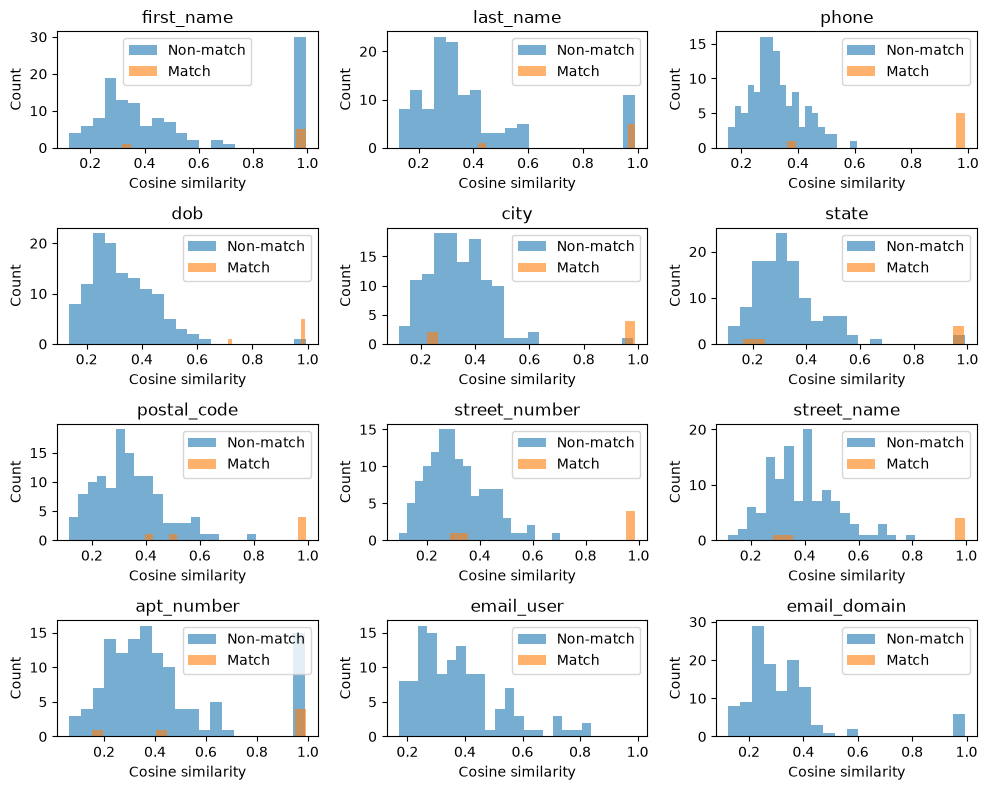

In [29]:
def plot_field_similarities(
    similarities,
    labels,
    fields
):

    labels = labels.cpu().numpy()

    fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10,8))

    # Flatten the 2D array of axes to easily iterate over them in a 1D loop
    flat_axes = axes.flatten()

    for ax, field in zip(flat_axes, fields):
        values = similarities[field].numpy()
        match_values = values[labels == 1]
        nonmatch_values = values[labels == 0]
        ax.hist(nonmatch_values, bins=20, alpha=0.6, label="Non-match")
        ax.hist(match_values, bins=20, alpha=0.6, label="Match")

        ax.set_title(field)
        ax.set_xlabel("Cosine similarity")
        ax.set_ylabel("Count")

        ax.legend()

    plt.tight_layout()
    plt.show()

plot_field_similarities(similarities, labels, fields)

### Posibilities

In [30]:
probabilities = torch.sigmoid(logits)

for i in range(len(labels)):
    print(
        f"Pair {i}: "
        f"label={labels[i].item():.0f}, "
        f"probability={probabilities[i].item():.4f}"
    )

Pair 0: label=0, probability=0.5627
Pair 1: label=0, probability=0.5864
Pair 2: label=0, probability=0.5998
Pair 3: label=1, probability=0.5971
Pair 4: label=0, probability=0.5567
Pair 5: label=0, probability=0.5598
Pair 6: label=0, probability=0.5514
Pair 7: label=0, probability=0.6566
Pair 8: label=0, probability=0.5596
Pair 9: label=0, probability=0.6249
Pair 10: label=0, probability=0.4968
Pair 11: label=0, probability=0.6147
Pair 12: label=0, probability=0.5435
Pair 13: label=0, probability=0.5899
Pair 14: label=0, probability=0.5458
Pair 15: label=0, probability=0.5676
Pair 16: label=0, probability=0.5123
Pair 17: label=0, probability=0.6248
Pair 18: label=0, probability=0.5397
Pair 19: label=0, probability=0.5598
Pair 20: label=0, probability=0.6074
Pair 21: label=0, probability=0.5903
Pair 22: label=0, probability=0.5289
Pair 23: label=0, probability=0.5447
Pair 24: label=0, probability=0.5380
Pair 25: label=0, probability=0.5900
Pair 26: label=0, probability=0.5350
Pair 27: la

### **One** training step

In [31]:
import torch.nn as nn

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

model.train()

batch_A, batch_B, labels = next(iter(train_loader))
batch_A = {field: batch_A[field].to(device) for field in fields}
batch_B = {field: batch_B[field].to(device) for field in fields}
labels = labels.to(device)

optimizer.zero_grad()

logits = model(batch_A, batch_B)
loss = criterion(logits, labels)

print("Loss before backward:", loss.item())
loss.backward()
optimizer.step()
print("One optimization step completed.")


Loss before backward: 0.8313778042793274
One optimization step completed.


In [32]:
for name, parameter in model.named_parameters():
    if parameter.grad is not None:
        print(f"{name:50s}", f"mean_grad={parameter.grad.abs().mean().item():.8f}")

encoders.first_name.embedding.weight               mean_grad=0.00007411
encoders.first_name.conv3.weight                   mean_grad=0.00052853
encoders.first_name.conv3.bias                     mean_grad=0.00005358
encoders.first_name.conv5.weight                   mean_grad=0.00049691
encoders.first_name.conv5.bias                     mean_grad=0.00001873
encoders.first_name.conv7.weight                   mean_grad=0.00049011
encoders.first_name.conv7.bias                     mean_grad=0.00002241
encoders.first_name.fc.0.weight                    mean_grad=0.00038670
encoders.first_name.fc.0.bias                      mean_grad=0.00000000
encoders.first_name.fc.1.weight                    mean_grad=0.00024894
encoders.first_name.fc.1.bias                      mean_grad=0.00018476
encoders.last_name.embedding.weight                mean_grad=0.00007313
encoders.last_name.conv3.weight                    mean_grad=0.00053592
encoders.last_name.conv3.bias                      mean_grad=0.0